In [ ]:
using Plots
using Random
using Statistics

In [ ]:
mutable struct Brownian_Dynamics
    # scale
    L::Float64          # size
    time::Float64
    iter::Int

    # physical quantities of molecules
    x
    y
    z

    y_grid

    random_x         # random force displacement
    random_y
    random_z
    force_x
    force_y
    force_z

    Lennard_Jones_ratio::Float64        # LJ force / gravity: ϵ / mgd
    random_force_ratio::Float64         # random force / gravity: kT / mgd

    # thermodynamical parameters
    N::Int                      # total number of molecules
    density::Float64            # number density of molecules
    volume_fraction::Float64    # volume fraction

    # hyper parameters
    dt::Float64
    y_slice::Int
    cutoff_radius::Float64  # cutoff radius of forces

    function _init_size_and_position(N, density; ϵ=0.0001)
        # set molecules at face centered cubic points
        lattice_constant = cbrt(4.0 / density)
        scale = Int(round(cbrt(N / 4.0)))
        L = lattice_constant * scale

        x_vec = []
        y_vec = []
        z_vec = []
        for layer = 1 : 4
            if layer  == 1
                x0 = ϵ
                y0 = ϵ
                z0 = ϵ
            elseif layer == 2
                x0 = 0.5 * lattice_constant
                y0 = 0.5 * lattice_constant
                z0 = ϵ
            elseif layer == 3
                x0 = 0.5 * lattice_constant
                y0 = ϵ
                z0 = 0.5 * lattice_constant
            elseif layer == 4
                x0 = ϵ
                y0 = 0.5 * lattice_constant
                z0 = 0.5 * lattice_constant
            end

            for z_index = 1 : scale
                z = lattice_constant * (z_index - 1) + z0
                if z >= L
                    break
                else
                    for y_index = 1 : scale
                        y = lattice_constant * (y_index - 1) + y0
                        if y >= L
                            break
                        else
                            for x_index = 1 : scale
                                x = lattice_constant * (x_index - 1) + x0
                                if x >= L
                                    break
                                end
                                push!(x_vec, x)
                                push!(y_vec, y)
                                push!(z_vec, z)
                            end
                        end
                    end
                end
            end
        end
        return L, x_vec, y_vec, z_vec
    end

    function Brownian_Dynamics(N, Lennard_Jones_ratio, random_force_ratio, volume_fraction; y_slice=40, dt=0.00005, cutoff_radius=2.5)
        density = volume_fraction * 6.0 / π
        iter = 0
        time = 0.0

        L, x, y, z = _init_size_and_position(N, density)

        grid_size = L / y_slice
        y_grid = [grid_size * i for i = 0 : N]

        force_x = zeros(N)
        force_y = zeros(N)
        force_z = zeros(N)
        random_x = zeros(N)
        random_y = zeros(N)
        random_z = zeros(N)

        new(L, time, iter, x, y, z, y_grid, random_x, random_y, random_z, force_x, force_y, force_z, Lennard_Jones_ratio, random_force_ratio,
            N, density, volume_fraction, dt, y_slice, cutoff_radius)
    end
end

function show_parameters(bd)
    println("scale: $(bd.L) * $(bd.L) * $(bd.L)\naverage density: $(bd.density), volume fraction: $(bd.volume_fraction), # of molecular: $(bd.N)")
    println("Lennard Jones force / gravitational force: $(bd.Lennard_Jones_ratio), random force / gravitational force: $(bd.random_force_ratio)")
    println("hyper parameters")
    println("dt: $(bd.dt), cutoff radius: $(bd.cutoff_radius), # of division along y axis: $(bd.y_slice)\n")
end

function solve!(bd, iter_max)
    show_parameters(bd)
    equilibration!(bd, iter=1000)
    plt = plot()

    while bd.iter <= iter_max
        force_update!(bd)
        random_force_update!(bd)
        position_update!(bd)
        plot_density!(bd, plt)
        bd.iter += 1
        bd.time += bd.dt
    end

    plot(plt)
    return plt
end

function equilibration!(bd; iter)
    for _ = 1 : iter
        force_update!(bd)
        random_force_update!(bd)
        position_update!(bd, gravity_flag=false)
    end
end

function force_update!(bd)
    force_x = zeros(bd.N)
    force_y = zeros(bd.N)
    force_z = zeros(bd.N)
    for i = 1 : bd.N-1
        x_temp = bd.x[i]
        y_temp = bd.y[i]
        z_temp = bd.z[i]
        force_x_temp = force_x[i]
        force_y_temp = force_y[i]
        force_z_temp = force_z[i]
        for j = i+1 : bd.N
            distance_x = x_temp - bd.x[j]
            distance_y = y_temp - bd.y[j]
            distance_z = z_temp - bd.z[j]

            # cyclic boundary condition
            distance_x -= round(distance_x / bd.L) * bd.L
            distance_y -= round(distance_y / bd.L) * bd.L
            distance_z -= round(distance_z / bd.L) * bd.L

            # cutoff
            distance_ij_squared = distance_x ^ 2 + distance_y ^ 2 + distance_z ^ 2
            if distance_ij_squared > (bd.cutoff_radius ^ 2)
                continue
            end

            # Lennard-Jones potential
            coef_6 = distance_ij_squared ^ (-3)
            coef_12 = coef_6 ^ 2
            scale = 24.0 * bd.Lennard_Jones_ratio * (2.0 * coef_12 - coef_6) / distance_ij_squared
            force_x_ij = scale * distance_x
            force_y_ij = scale * distance_y
            force_z_ij = scale * distance_z
            force_x_temp += force_x_ij
            force_y_temp += force_y_ij
            force_z_temp += force_z_ij
            force_x[j] -= force_x_ij
            force_y[j] -= force_y_ij
            force_z[j] -= force_z_ij
        end
        force_x[i] = force_x_temp
        force_y[i] = force_y_temp
        force_z[i] = force_z_temp
    end

    bd.force_x = force_x
    bd.force_y = force_y
    bd.force_z = force_z
end

function random_force_update!(bd)
        random_x = []
        random_y = []
        random_z = []
        for array ∈ [random_x, random_y, random_z]
            for _ = 1 : bd.N
                box_muller_1 = sqrt(4.0 * bd.dt * bd.random_force_ratio * (-log(rand(Float64))))
                box_muller_2 = 2.0 * π * rand(Float64)
                push!(array, box_muller_1 * cos(box_muller_2))
            end
        end

        bd.random_x = random_x
        bd.random_y = random_y
        bd.random_z = random_z
    end

function position_update!(bd; gravity_flag=true)
    if gravity_flag
        g = -1.0
    else
        g = 0.0
    end

    for i = 1 : bd.N
        temp_x = bd.x[i] + bd.random_x[i] + bd.force_x[i] * bd.dt
        temp_y = bd.y[i] + bd.random_y[i] + (bd.force_y[i] + g) * bd.dt
        temp_z = bd.z[i] + bd.random_z[i] + bd.force_z[i] * bd.dt
        # boundary condition of x, z: cyclic condition
        temp_x -= round(temp_x / bd.L - 0.5) * bd.L
        temp_z -= round(temp_z / bd.L - 0.5) * bd.L
        # boundary condition of y: elastic reflection
        if temp_y < 0.0
            temp_y = -temp_y
        elseif temp_y > bd.L
            temp_y = bd.L - (temp_y - bd.L)
        end
        bd.x[i] = temp_x
        bd.y[i] = temp_y
        bd.z[i] = temp_z
    end
end

function plot_density!(bd, plt)
    time_temp = floor(bd.time + bd.dt)
    if time_temp == floor(bd.time) + 1.0
        density_distribution = _density_calculation(bd)
        plot!(plt, bd.y_grid[2 : bd.y_slice + 1], density_distribution, label="t = $(time_temp)")
    end
end

function _density_calculation(bd)
    density_distribution = []
    for j = 1 : bd.y_slice
        count = 0
        for i = 1 : bd.N
            if bd.y_grid[j] <= bd.y[i] < bd.y_grid[j+1]
                count += 1
            end
        end
        push!(density_distribution, count / bd.N)
    end

    return density_distribution
end

function plot_position(bd)
    scatter(bd.x, bd.y, label="molecules")
end

plot_position (generic function with 1 method)

In [ ]:
N = 108
R_LJ = 1.0
R_B = 0.1
volume_fraction = 0.1

bd = Brownian_Dynamics(N, R_LJ, R_B, volume_fraction)
show_parameters(bd)

scale: 8.269402402813594 * 8.269402402813594 * 8.269402402813594
average density: 0.19098593171027445, volume fraction: 0.1, # of molecular: 108
Lennard Jones force / gravitational force: 1.0, random force / gravitational force: 0.1
hyper parameters
dt: 5.0e-5, cutoff radius: 2.5, # of division along y axis: 40



scale: 8.269402402813594 * 8.269402402813594 * 8.269402402813594
average density: 0.19098593171027445, volume fraction: 0.1, # of molecular: 108
Lennard Jones force / gravitational force: 1.0, random force / gravitational force: 0.1
hyper parameters
dt: 5.0e-5, cutoff radius: 2.5, # of division along y axis: 40



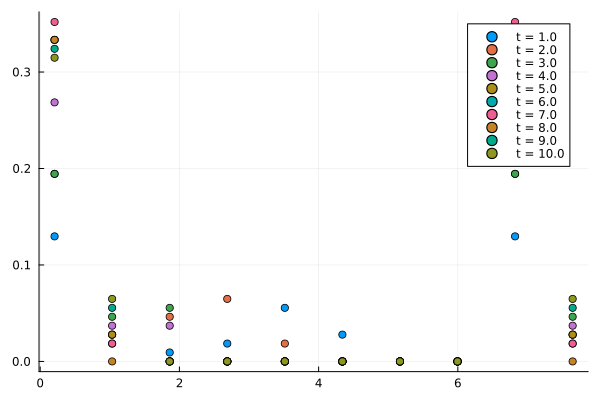

In [ ]:
plt = solve!(bd, 200001)

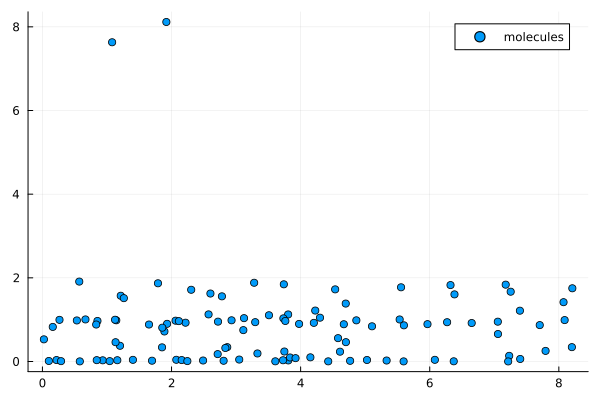

In [ ]:
plot_position(bd)